# Goal:
# 1) Count how many times each element appears in the database
#    and show a pie chart.
# 2) Train a GNN on materials containing the most frequent element,
#    and test on materials containing the second most frequent element,
#    reporting R^2, MSE, and a parity plot.

In [1]:
# -----------------------
# 0) Install dependencies
# -----------------------
!pip -q install torch-geometric
!pip -q install pandas numpy matplotlib scikit-learn tqdm

import math
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
from torch.utils.data import DataLoader

from sklearn.metrics import r2_score, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from typing import List, Dict, Tuple, Optional

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.0 MB/s eta 0:00:00


In [2]:
# -----------------------
# 1) Reproducibility
# -----------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [4]:
# -----------------------
# 2) Data loading
# -----------------------
BASE = "https://www.aflowlib.org/API/aflux/"

SELECT = (
    "$catalog(icsd),"
    "compound(*),"
    "auid(*),"
    "agl_debye(*),"
    "agl_acoustic_debye(*),"
    "ael_debye_temperature(*),"
    "agl_gruneisen(*),"
    "agl_heat_capacity_Cv_300K(*),"
    "agl_thermal_conductivity_300K(*),"
    "agl_thermal_expansion_300K(*),"
    "positions_fractional(*),"
    "geometry(*),"
    "$format(json)"
)

PER_PAGE = 500
MAX_PAGES = 15

TARGET_KEY = "agl_thermal_conductivity_300K"

GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "agl_acoustic_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

POSITION_KEYS = ["positions_fractional", "positions_frac", "positions"]
LATTICE_KEYS  = ["lattice_vectors", "lattice", "cell"]
SPECIES_KEYS  = ["species", "elements", "atomic_symbols"]

session = requests.Session()
session.headers.update({"User-Agent": "colab-aflux-client/1.0"})

In [5]:
KNN_K = 12
EDGE_EPS = 1e-8 #so 1/d+eps cannot be infinity

BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
VAL_RATIO = 0.1
HIDDEN = 128
DEPTH = 3


In [6]:
def fetch_page(page: int):
    """
    Fetch ONE page of AFLOW entries using aflux paging.

    Parameters
    ----------
    page : int
        Page index (1-based).

    Returns
    -------
    rows : list[dict]
        A list of AFLOW entries (JSON objects).
    url : str
        The exact URL used (for debugging / reproducibility).
    """
    url = f"{BASE}?{SELECT},$paging({page},{PER_PAGE})"

    r = session.get(url, timeout=120)
    r.raise_for_status()          # HTTP-level errors (404 / 500 / etc.)

    data = r.json()               # <-- AFLOW returns a LIST here
    if not isinstance(data, list):
        raise ValueError(
            f"Unexpected AFLOW response type: {type(data)}\nURL: {url}"
        )

    return data, url

In [7]:
def fetch_all_aflow(
    max_pages: int = MAX_PAGES,
    per_page: int = PER_PAGE,
):
    """
    Fetch all AFLOW entries using paging.
    Returns
    -------
    df : pd.DataFrame
    """
    all_rows = []
    last_url = None

    for page in tqdm(range(1, max_pages + 1), desc="Paging AFLOW"):
        rows, last_url = fetch_page(page)
        if len(rows) == 0:
            break
        all_rows.extend(rows)

    print(f"Fetched {len(all_rows)} entries.")
    print("Last URL:", last_url)
    return pd.DataFrame(all_rows)


In [8]:
df = fetch_all_aflow()


Paging AFLOW:  80%|████████  | 12/15 [00:34<00:08,  2.88s/it]

Fetched 5553 entries.
Last URL: https://www.aflowlib.org/API/aflux/?$catalog(icsd),compound(*),auid(*),agl_debye(*),agl_acoustic_debye(*),ael_debye_temperature(*),agl_gruneisen(*),agl_heat_capacity_Cv_300K(*),agl_thermal_conductivity_300K(*),agl_thermal_expansion_300K(*),positions_fractional(*),geometry(*),$format(json),$paging(13,500)


In [9]:
# ============================================================
# 3) Element parsing and counting
# ============================================================

# --- Parse chemical formula like "Al2O3", "Si", "Cu1Hf1Hg2"
#     Handles simple formulas without parentheses.
ELEMENT_RE = re.compile(r"([A-Z][a-z]?)(\d*\.?\d*)")

def parse_formula_simple(formula: str) -> dict:
    """
    Parse a simple chemical formula into element->count.
    Example: "Al2O3" -> {"Al":2, "O":3}
    If no number -> 1
    """
    if not isinstance(formula, str) or len(formula) == 0:
        return {}
    out = {}
    for (el, num) in ELEMENT_RE.findall(formula):
        if num == "" or num is None:
            c = 1.0
        else:
            c = float(num)
        out[el] = out.get(el, 0.0) + c
    return out

In [10]:
def count_elements_from_df(df: pd.DataFrame, formula_col="compound") -> pd.Series:
    """
    Count total occurrences of each element (sum of stoichiometric coefficients)
    across the entire dataset.
    """
    counts = {}
    for f in df[formula_col].astype(str).tolist():
        comp = parse_formula_simple(f)
        for el, c in comp.items():
            counts[el] = counts.get(el, 0.0) + float(c)
    s = pd.Series(counts).sort_values(ascending=False)
    return s

elem_counts = count_elements_from_df(df, formula_col="compound")
print("Top 20 elements by total stoichiometric count:")
print(elem_counts.head(20))


Top 20 elements by total stoichiometric count:
O     4618.0
Si    2252.0
Al    2027.0
Ge    1820.0
S     1468.0
C     1351.0
Sn    1338.0
Ni    1262.0
B     1213.0
Sb    1199.0
Pd    1193.0
P     1155.0
Rh    1136.0
Zr    1118.0
N     1117.0
Pt    1110.0
Mg     925.0
Se     900.0
Be     898.0
Ir     889.0
dtype: float64


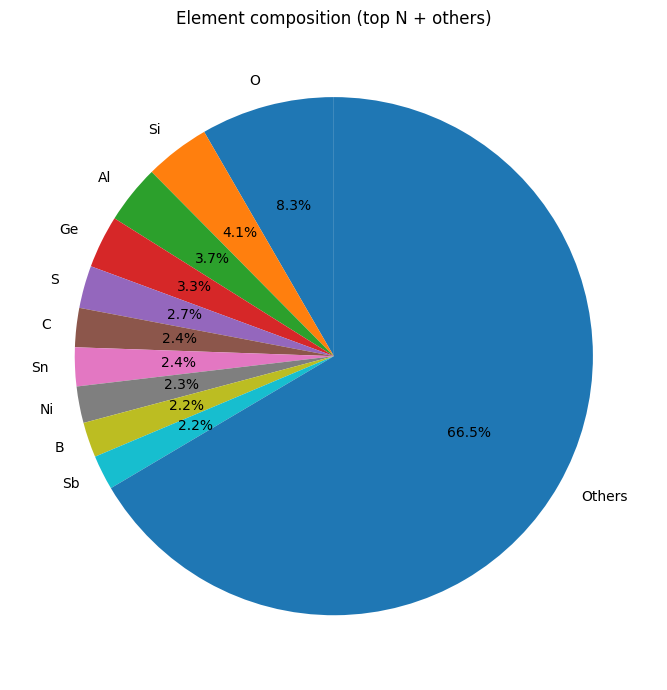

Most frequent element: O
2nd most frequent element: Si


In [11]:
# -----------------------
# 3.1) Pie chart (Top N + Others)
# -----------------------
def pie_top_elements(elem_counts: pd.Series, top_n=10, title="Element composition (top N + others)"):
    top = elem_counts.head(top_n)
    others = elem_counts.iloc[top_n:].sum()
    labels = list(top.index) + (["Others"] if others > 0 else [])
    sizes  = list(top.values) + ([others] if others > 0 else [])
    plt.figure(figsize=(7,7))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

pie_top_elements(elem_counts, top_n=10)

top1_el = elem_counts.index[0]
top2_el = elem_counts.index[1] if len(elem_counts) > 1 else None
print("Most frequent element:", top1_el)
print("2nd most frequent element:", top2_el)

1.oxides over oxides/ nitrites over nitrites
2.2 chemically similare.g. metals
3.structural category e.g. FCC vs HCP

1. changing k and changing number of message passing layers (ranges) -> guess: not too important as further away, less interaction

Element count distribution:
1 elements: 96 materials
2 elements: 2530 materials
3 elements: 2927 materials


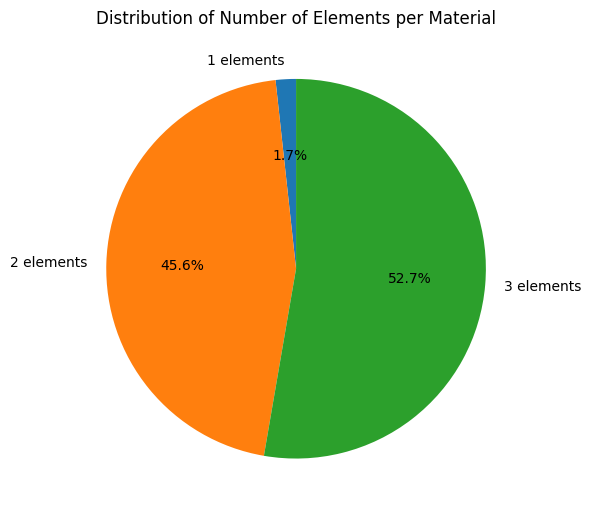

In [12]:
import re
import matplotlib.pyplot as plt
from collections import Counter

# -------- 1. 解析每个 compound 中有多少种不同元素 --------

def count_unique_elements(formula: str) -> int:
    """
    Count number of unique chemical elements in a formula string.
    Example:
        "SiO2" -> 2
        "BaTiO3" -> 3
        "Fe" -> 1
    """
    # 正则匹配元素符号：大写字母 + 可选小写字母
    elements = re.findall(r"[A-Z][a-z]?", formula)
    unique_elements = set(elements)
    return len(unique_elements)

# 统计每个材料的元素种类数
element_counts = df["compound"].astype(str).apply(count_unique_elements)

# -------- 2. 统计分布 --------

count_distribution = Counter(element_counts)

print("Element count distribution:")
for k in sorted(count_distribution.keys()):
    print(f"{k} elements: {count_distribution[k]} materials")

# -------- 3. 画 Pie Chart --------

labels = []
sizes = []

for k in sorted(count_distribution.keys()):
    labels.append(f"{k} elements")
    sizes.append(count_distribution[k])

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Number of Elements per Material")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 4) Filter dataframe by "contains element"
# ============================================================

def contains_element(formula: str, element: str) -> bool:
    comp = parse_formula_simple(formula)
    return element in comp and comp[element] > 0

df_top1 = df[df["compound"].astype(str).apply(lambda x: contains_element(x, top1_el))].copy()
df_top2 = df[df["compound"].astype(str).apply(lambda x: contains_element(x, top2_el))].copy() if top2_el else pd.DataFrame()

# Prefer making test set EXCLUSIVE (top2 but not top1) to avoid leakage.
if top2_el is not None:
    df_top2_excl = df_top2[~df_top2["compound"].astype(str).apply(lambda x: contains_element(x, top1_el))].copy()
    if len(df_top2_excl) < 50:
        print(f"[Warn] Exclusive test set (contains {top2_el} but not {top1_el}) is small: {len(df_top2_excl)}.")
        print("       Falling back to all materials containing the 2nd element.")
        df_test = df_top2
    else:
        df_test = df_top2_excl
else:
    df_test = pd.DataFrame()

print("Train pool size (contains top element):", len(df_top1))
print("Test pool size  (contains 2nd element):", len(df_test))


Train pool size (contains top element): 598
Test pool size  (contains 2nd element): 418


In [14]:
for i in [0, 1, 2, 3, 4]:
    frac = np.asarray(df_top1.iloc[i]["positions_fractional"], dtype=float)
    print(i, frac.shape, "finite=", np.isfinite(frac).all())

0 (8, 3) finite= True
1 (4, 3) finite= True
2 (32, 3) finite= True
3 (5, 3) finite= True
4 (5, 3) finite= True


In [15]:
# ============================================================
# 5) Graph building
# ============================================================
TARGET_KEY = "agl_thermal_conductivity_300K"
PERIODIC_TABLE = {
    "H": (1, 1.008), "He": (2, 4.002602), "Li": (3, 6.94), "Be": (4, 9.0121831),
    "B": (5, 10.81), "C": (6, 12.011), "N": (7, 14.007), "O": (8, 15.999),
    "F": (9, 18.998403163), "Ne": (10, 20.1797), "Na": (11, 22.98976928), "Mg": (12, 24.305),
    "Al": (13, 26.9815385), "Si": (14, 28.085), "P": (15, 30.973761998), "S": (16, 32.06),
    "Cl": (17, 35.45), "Ar": (18, 39.948), "K": (19, 39.0983), "Ca": (20, 40.078),
    "Sc": (21, 44.955908), "Ti": (22, 47.867), "V": (23, 50.9415), "Cr": (24, 51.9961),
    "Mn": (25, 54.938044), "Fe": (26, 55.845), "Co": (27, 58.933194), "Ni": (28, 58.6934),
    "Cu": (29, 63.546), "Zn": (30, 65.38), "Ga": (31, 69.723), "Ge": (32, 72.63),
    "As": (33, 74.921595), "Se": (34, 78.971), "Br": (35, 79.904), "Kr": (36, 83.798),
    "Rb": (37, 85.4678), "Sr": (38, 87.62), "Y": (39, 88.90584), "Zr": (40, 91.224),
    "Nb": (41, 92.90637), "Mo": (42, 95.95), "Tc": (43, 98.0), "Ru": (44, 101.07),
    "Rh": (45, 102.9055), "Pd": (46, 106.42), "Ag": (47, 107.8682), "Cd": (48, 112.414),
    "In": (49, 114.818), "Sn": (50, 118.71), "Sb": (51, 121.76), "Te": (52, 127.6),
    "I": (53, 126.90447), "Xe": (54, 131.293), "Cs": (55, 132.90545196), "Ba": (56, 137.327),
    "La": (57, 138.90547), "Ce": (58, 140.116), "Pr": (59, 140.90766), "Nd": (60, 144.242),
    "Pm": (61, 145.0), "Sm": (62, 150.36), "Eu": (63, 151.964), "Gd": (64, 157.25),
    "Tb": (65, 158.92535), "Dy": (66, 162.5), "Ho": (67, 164.93033), "Er": (68, 167.259),
    "Tm": (69, 168.93422), "Yb": (70, 173.045), "Lu": (71, 174.9668), "Hf": (72, 178.49),
    "Ta": (73, 180.94788), "W": (74, 183.84), "Re": (75, 186.207), "Os": (76, 190.23),
    "Ir": (77, 192.217), "Pt": (78, 195.084), "Au": (79, 196.966569), "Hg": (80, 200.592),
    "Tl": (81, 204.38), "Pb": (82, 207.2), "Bi": (83, 208.9804), "Po": (84, 209.0),
    "At": (85, 210.0), "Rn": (86, 222.0), "Fr": (87, 223.0), "Ra": (88, 226.0),
    "Ac": (89, 227.0), "Th": (90, 232.0377), "Pa": (91, 231.03588), "U": (92, 238.02891),
    "Np": (93, 237.0), "Pu": (94, 244.0), "Am": (95, 243.0), "Cm": (96, 247.0),
    "Bk": (97, 247.0), "Cf": (98, 251.0), "Es": (99, 252.0), "Fm": (100, 257.0),
    "Md": (101, 258.0), "No": (102, 259.0), "Lr": (103, 266.0), "Rf": (104, 267.0),
    "Db": (105, 268.0), "Sg": (106, 269.0), "Bh": (107, 270.0), "Hs": (108, 277.0),
    "Mt": (109, 278.0), "Ds": (110, 281.0), "Rg": (111, 282.0), "Cn": (112, 285.0),
    "Nh": (113, 286.0), "Fl": (114, 289.0), "Mc": (115, 290.0), "Lv": (116, 293.0),
    "Ts": (117, 294.0), "Og": (118, 294.0),
}



In [16]:
TARGET_KEY = "agl_thermal_conductivity_300K"
POS_KEY    = "positions_fractional"
LAT_KEY    = "lattice_vectors"

GLOBAL_FEATURE_KEYS = [
    "agl_debye",
    "ael_debye_temperature",
    "agl_gruneisen",
    "agl_heat_capacity_Cv_300K",
    "agl_thermal_expansion_300K",
]

EDGE_EPS = 1e-6


In [17]:
def parse_formula(formula: str):
    '''
    Simple regex formula parser (no parentheses).
    Returns expanded elements list and counts dict.
    '''
    tokens = re.findall(r"([A-Z][a-z]?)(\d*)", str(formula))
    counts = {}
    expanded = []
    for sym, num in tokens:
        n = int(num) if num else 1
        counts[sym] = counts.get(sym, 0) + n
        expanded.extend([sym] * n)
    return expanded, counts

In [18]:
def assign_masses(compound: str):
    '''
    Expand formula into per-atom Z and mass lists.
    '''
    elems, _ = parse_formula(compound)
    masses, Zs = [], []
    for sym in elems:
        Z, m = PERIODIC_TABLE[sym]
        Zs.append(int(Z))
        masses.append(float(m))
    return masses, Zs

In [19]:
def _wrap_frac_delta(df: np.ndarray):
    '''Wrap fractional coordinate delta into [-0.5, 0.5] for minimum-image convention.'''
    return df - np.round(df)

def distance_matrix_safe(frac: np.ndarray, lattice: np.ndarray | None) -> np.ndarray:
    """
    If lattice is provided: proper PBC distance in Cartesian space.
    If lattice is None: fallback distance in fractional space (approx).
    """
    frac = np.asarray(frac, dtype=float)
    dfrac = frac[None, :, :] - frac[:, None, :]
    dfrac = _wrap_frac_delta(dfrac)                 # minimum-image in fractional coords

    if lattice is None:
        dvec = dfrac                                # approximate: fractional treated as Euclidean
    else:
        lattice = np.asarray(lattice, dtype=float)
        dvec = dfrac @ lattice                       # Cartesian displacement

    D = np.linalg.norm(dvec, axis=-1)
    np.fill_diagonal(D, np.inf)
    return D

def assign_edges_knn(frac: np.ndarray, lattice: np.ndarray, k: int = 12):
    """
    Build directed kNN edges under PBC.
    returns edge_index (2,E) torch.LongTensor, dist_list (E,) np.ndarray
    """
    D = distance_matrix_safe(frac, lattice)
    N = D.shape[0]
    src, dst, dist = [], [], []
    for i in range(N):
        nn = np.argsort(D[i])[:k]
        for j in nn:
            src.append(i)
            dst.append(int(j))
            dist.append(float(D[i, j]))
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    dist_list = np.array(dist, dtype=float)
    return edge_index, dist_list

def assign_edge_attributes(dist_list, eps=1e-6):
    """
    dist_list: array-like shape (E,)
    returns edge_attr: Tensor shape (E,2) = [d, 1/(d+eps)]
    """
    d = np.asarray(dist_list, dtype=float)

    # strict checks
    if d.ndim != 1:
        raise ValueError(f"dist_list must be 1D, got shape {d.shape}")
    if not np.isfinite(d).all():
        # print a few bad indices for debugging
        bad = np.where(~np.isfinite(d))[0][:10]
        raise ValueError(f"dist_list contains NaN/inf at indices {bad.tolist()}")

    d = d.astype(np.float32)
    inv = (1.0 / (d + eps)).astype(np.float32)

    edge_attr = np.stack([d, inv], axis=1)  # (E,2)

    if not np.isfinite(edge_attr).all():
        raise ValueError("edge_attr became NaN/inf after stacking")

    return torch.tensor(edge_attr, dtype=torch.float32)

def assign_global_attributes(entry: dict, keys: list[str]) -> torch.Tensor:
    """Global features vector u: shape (u_dim,) -> caller will reshape to (1,u_dim)."""
    vals = []
    for k in keys:
        v = entry.get(k, np.nan)
        v = float(v)
        if not np.isfinite(v):
            # choose a policy: either raise or impute
            # here: raise, because NaNs silently break training
            raise ValueError(f"Global feature {k} is NaN/inf")
        vals.append(v)
    return torch.tensor(vals, dtype=torch.float32)

In [20]:
def build_graph_from_entry(entry: dict, k: int = 12) -> Data:
    """
    Build one PyG graph using your columns:
      - positions_fractional
      - lattice_vectors
      - compound (for node features via assign_masses)
      - global features keys above
      - target agl_thermal_conductivity_300K -> y=log1p(kappa)
    """
    # ---- positions + lattice ----
    frac = np.array(entry[POS_KEY], dtype=float)
    if frac.ndim != 2 or frac.shape[1] != 3:
        raise ValueError(f"{POS_KEY} has invalid shape {frac.shape}")

    lattice = entry.get(LAT_KEY, None)
    if lattice is not None:
      lattice = np.array(lattice, dtype=float)
      if lattice.shape != (3, 3):
        raise ValueError(f"{LAT_KEY} must be (3,3), got {lattice.shape}")

    # ---- node features from compound (fallback) ----
    compound = entry.get("compound", None)
    if compound is None:
        raise KeyError("Missing compound")
    masses, Zs = assign_masses(compound)  # from your existing notebook
    if len(masses) != frac.shape[0]:
        raise ValueError(
            f"Expanded atoms from compound ({len(masses)}) != number of positions ({frac.shape[0]}). "
            f"Need per-site species to avoid this."
        )
    x = torch.tensor(np.stack([Zs, masses], axis=1), dtype=torch.float32)  # (N,2)

    # ---- edges ----
    edge_index, dist_list = assign_edges_knn(frac, lattice=None, k=k)
    dist_list = np.asarray(dist_list, dtype=float)
    print("dist_list finite?", np.isfinite(dist_list).all(), "min/max:", np.nanmin(dist_list), np.nanmax(dist_list))

    edge_attr = assign_edge_attributes(dist_list, eps=EDGE_EPS)
    print("edge_attr col0 finite?", torch.isfinite(edge_attr[:,0]).all().item())
    # ---- global u ----
    u = assign_global_attributes(entry, GLOBAL_FEATURE_KEYS).view(1, -1)  # (1,u_dim)

    # ---- target ----
    y_raw = entry.get(TARGET_KEY, None)
    if y_raw is None:
        raise ValueError(f"Missing target {TARGET_KEY}")
    kappa = float(y_raw)
    if not np.isfinite(kappa) or kappa <= 0:
        raise ValueError(f"Invalid target {TARGET_KEY}={y_raw}")
    y = torch.tensor([[math.log1p(kappa)]], dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, u=u, y=y)
    data.compound = str(compound)
    data.auid = str(entry.get("auid", ""))
    return data

In [21]:
def df_to_graphs(df: pd.DataFrame, k: int = 12, limit=None):
    graphs, skipped = [], []
    n = len(df) if limit is None else min(len(df), limit)
    for i in tqdm(range(n), desc="Building graphs"):
        entry = df.iloc[i].to_dict()
        try:
            graphs.append(build_graph_from_entry(entry, k=k))
        except Exception as e:
            skipped.append((i, str(e)))
    print(f"Built graphs: {len(graphs)} / {n}, skipped: {len(skipped)}")
    if len(skipped) > 0:
        print("Example skip:", skipped[0])
    return graphs, skipped

In [22]:
# Build graphs for train pool and test pool
KNN_K = 12
train_graphs_all, sk1 = df_to_graphs(df_top1, k=KNN_K)
test_graphs, sk2 = df_to_graphs(df_test, k=KNN_K)

assert len(train_graphs_all) > 200, "Train pool too small after graph building."
assert len(test_graphs) > 50, "Test pool too small after graph building."

Building graphs:  10%|▉         | 59/598 [00:00<00:01, 323.96it/s]

dist_list finite? False min/max: 0.1648365003791636 inf
dist_list finite? False min/max: 0.14341800000000002 inf
dist_list finite? True min/max: 0.21936273775187978 0.4884902646051403
edge_attr col0 finite? True
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.1680660015232111 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? True min/max: 0.3535533905932738 0.7071067811865476
edge_attr col0 finite? True
dist_list finite? False min/max: 0.25235368721308593 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.20185839726649965 inf
dist_list finite? False min/max: 0.4337760691324499 inf
dist_list finite? False min/max: 0.3651874431836341 inf
dist_list finite? True min/max: 0.1533627067053786 0.6867774543962549
edge_attr col0 finite? True
dist_list finite? False

Building graphs:  27%|██▋       | 161/598 [00:00<00:00, 464.49it/s]

dist_list finite? False min/max: 0.5 inf
dist_list finite? True min/max: 0.20416059783415605 0.616010862039315
edge_attr col0 finite? True
dist_list finite? False min/max: 0.5 inf
dist_list finite? True min/max: 0.20428597158640138 0.6047136457843663
edge_attr col0 finite? True
dist_list finite? False min/max: 0.3280494632094374 inf
dist_list finite? False min/max: 0.8660254037844386 inf
dist_list finite? False min/max: 0.8660254037844386 inf
dist_list finite? True min/max: 0.30846669933730286 0.5781360272008742
edge_attr col0 finite? True
dist_list finite? True min/max: 0.19540598771555082 0.45756991771531486
edge_attr col0 finite? True
dist_list finite? False min/max: 0.2844275972563141 inf
dist_list finite? False min/max: 0.26679144341243405 inf
dist_list finite? True min/max: 0.28606352557236303 0.5702253176087502
edge_attr col0 finite? True
dist_list finite? True min/max: 0.21923787963451938 0.42584508287502865
edge_attr col0 finite? True
dist_list finite? False min/max: 0.5 inf
d

Building graphs:  35%|███▍      | 208/598 [00:00<00:00, 405.31it/s]

...

dist_list finite? False min/max: 0.35095972291988153 inf
dist_list finite? False min/max: 0.19963180067814845 inf
dist_list finite? False min/max: 0.33959803155548474 inf
dist_list finite? False min/max: 0.338740640233734 inf
dist_list finite? False min/max: 0.3438108763739158 inf
dist_list finite? False min/max: 0.3439157384738302 inf
dist_list finite? False min/max: 0.1942422327919446 inf
dist_list finite? True min/max: 0.204522604100378 0.48497967019041116
edge_attr col0 finite? True
dist_list finite? True min/max: 0.22791017346314302 0.37550553039602497
edge_attr col0 finite? True
dist_list finite? False min/max: 0.34043231716157624 inf
dist_list finite? False min/max: 0.3589874950527525 inf
dist_list finite? False min/max: 0.3642465339849372 inf
dist_list finite? False min/max: 0.43465965283195995 inf
dist_list finite? False min/max: 0.32926702064585817 inf
dist_list finite? False min/max: 0.42237240806365417 inf
dist_list finite? False min/max: 0.47144081893913264 inf
dist_list f

Building graphs:  92%|█████████▏| 383/418 [00:00<00:00, 629.55it/s]

dist_list finite? False min/max: 0.355109 inf
dist_list finite? False min/max: 0.3351245899960192 inf
dist_list finite? False min/max: 0.3435860134056682 inf
dist_list finite? False min/max: 0.3440807705757472 inf
dist_list finite? False min/max: 0.3741895948954219 inf
dist_list finite? False min/max: 0.4714125346678851 inf
dist_list finite? False min/max: 0.41525269989248714 inf
dist_list finite? True min/max: 0.18745543524261976 0.445882545446668
edge_attr col0 finite? True
dist_list finite? False min/max: 0.7071067811865476 inf
dist_list finite? False min/max: 0.36866850514791744 inf
dist_list finite? False min/max: 0.35485227251491575 inf
dist_list finite? False min/max: 0.3340633971643705 inf
dist_list finite? True min/max: 0.2888558778311599 0.7071067811865476
edge_attr col0 finite? True
dist_list finite? False min/max: 0.3440986299704097 inf
dist_list finite? False min/max: 0.34769880731460673 inf
dist_list finite? True min/max: 0.22435254110439654 0.3777216128539642
edge_attr c

Building graphs: 100%|██████████| 418/418 [00:00<00:00, 501.52it/s]

dist_list finite? False min/max: 0.33213734809563344 inf
dist_list finite? True min/max: 0.211471984506719 0.6433215042045463
edge_attr col0 finite? True
dist_list finite? False min/max: 0.3784576914266639 inf
dist_list finite? False min/max: 0.24428499999999997 inf
dist_list finite? False min/max: 0.3845925498602385 inf
dist_list finite? False min/max: 0.35409663635685673 inf
dist_list finite? True min/max: 0.2561817164615969 0.4881958335025095
edge_attr col0 finite? True
dist_list finite? False min/max: 0.24252700000000002 inf
dist_list finite? False min/max: 0.39312400000000003 inf
dist_list finite? False min/max: 0.5012000780845909 inf
dist_list finite? True min/max: 0.17787699999999995 0.6251132230580314
edge_attr col0 finite? True
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.32925154473745444 inf
dist_list finite? False min/max: 0.3357371324622881 inf
dist_list finite? False min/max: 0.3596399844983869 inf
dist_list finite? False min/

In [23]:
print(df.columns.tolist())

['compound', 'auid', 'aurl', 'spacegroup_relax', 'Pearson_symbol_relax', 'agl_debye', 'agl_acoustic_debye', 'ael_debye_temperature', 'agl_gruneisen', 'agl_heat_capacity_Cv_300K', 'agl_thermal_conductivity_300K', 'agl_thermal_expansion_300K', 'positions_fractional', 'geometry']


In [24]:
# ============================================================
# 6) Split train/val inside top-element pool
# ============================================================
def split_train_val(graphs, val_ratio=0.1, seed=42):
    idx = list(range(len(graphs)))
    rng = random.Random(seed)
    rng.shuffle(idx)
    n = len(idx)
    n_val = int(val_ratio * n)
    val_idx = idx[:n_val]
    tr_idx  = idx[n_val:]
    tr = [graphs[i] for i in tr_idx]
    va = [graphs[i] for i in val_idx]
    return tr, va

train_graphs, val_graphs = split_train_val(train_graphs_all, val_ratio=0.1, seed=42)

In [25]:
# ============================================================
# 7) Feature scaling (train-fit, apply to all)
# ============================================================
def fit_feature_scalers(train_graphs):
    # node: mass scaling (no log)
    mass = torch.cat([g.x[:, 1] for g in train_graphs]).float()
    mass_mu = mass.mean().item()
    mass_std = mass.std(unbiased=False).item() or 1.0

    # edge
    E = torch.cat([g.edge_attr for g in train_graphs], dim=0).float()
    e_mu = E.mean(dim=0)
    e_std = E.std(dim=0, unbiased=False)
    e_std[e_std < 1e-12] = 1.0

    # global u
    u_dim = train_graphs[0].u.size(-1)
    if u_dim > 0:
        U = torch.cat([g.u for g in train_graphs], dim=0).float()
        u_mu = U.mean(dim=0)
        u_std = U.std(dim=0, unbiased=False)
        u_std[u_std < 1e-12] = 1.0
    else:
        u_mu = torch.zeros((0,), dtype=torch.float32)
        u_std = torch.ones((0,), dtype=torch.float32)

    return {"mass_mu": mass_mu, "mass_std": mass_std, "e_mu": e_mu, "e_std": e_std, "u_mu": u_mu, "u_std": u_std}


In [26]:
def apply_feature_scalers(graphs, scalers):
    for g in graphs:
        # node: Z scaled, mass standardized (NO LOG)
        Z = g.x[:, 0:1] / 100.0
        mass = g.x[:, 1:2]
        mass = (mass - scalers["mass_mu"]) / scalers["mass_std"]
        g.x = torch.cat([Z, mass], dim=1)

        # edge
        g.edge_attr = (g.edge_attr - scalers["e_mu"]) / scalers["e_std"]

        # global
        if g.u.numel() > 0:
            g.u = (g.u - scalers["u_mu"]) / scalers["u_std"]

In [27]:
g = train_graphs[0]
print("edge_attr finite:", torch.isfinite(g.edge_attr).all().item())
print("edge_attr first rows:\n", g.edge_attr[:5])

edge_attr finite: True
edge_attr first rows:
 tensor([[0.3615, 2.7666],
        [0.3661, 2.7313],
        [0.3720, 2.6884],
        [0.3904, 2.5617],
        [0.4045, 2.4719]])


In [28]:
scalers = fit_feature_scalers(train_graphs)
apply_feature_scalers(train_graphs, scalers)
apply_feature_scalers(val_graphs, scalers)
apply_feature_scalers(test_graphs, scalers)

In [29]:
# ============================================================
# 8) GNN Model (Graph + optional global u)
# ============================================================
class GraphRegressor(nn.Module):
    """
    Simple GINE-based regressor:
    - Node embeddings -> message passing -> pooled graph embedding
    - Concatenate global u (if present) -> MLP -> predict log1p(kappa)
    """
    def __init__(self, x_dim, e_dim, u_dim, hidden=128, depth=3):
        super().__init__()
        self.node_in = nn.Linear(x_dim, hidden)

        mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.convs = nn.ModuleList([GINEConv(mlp, edge_dim=e_dim) for _ in range(depth)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(depth)])

        self.u_dim = u_dim
        out_in = hidden + (u_dim if u_dim > 0 else 0)
        self.head = nn.Sequential(
            nn.Linear(out_in, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, batch):
        """
        batch is a PyG Batch, containing:
          batch.x         (sum_N, x_dim)
          batch.edge_index(2, sum_E)
          batch.edge_attr (sum_E, e_dim)
          batch.batch     (sum_N,) graph id for each node
          batch.u         (num_graphs, u_dim)  [if provided in Data]
        """
        x = batch.x
        edge_index = batch.edge_index
        edge_attr = batch.edge_attr
        batch_idx = batch.batch

        h = self.node_in(x)

        for conv, norm in zip(self.convs, self.norms):
            h = conv(h, edge_index, edge_attr)
            h = norm(h)
            h = F.relu(h)

        g = global_mean_pool(h, batch_idx)  # (num_graphs, hidden)

        # concatenate global features if present
        if self.u_dim > 0 and hasattr(batch, "u") and batch.u is not None:
            # in PyG batching: g.u should become (num_graphs, u_dim) if each graph had (1,u_dim)
            gu = torch.cat([g, batch.u], dim=1)
        else:
            gu = g

        y_hat = self.head(gu).view(-1)  # (num_graphs,)
        return y_hat


In [30]:
# ============================================================
# 9) Train (on top-element pool), Evaluate on 2nd-element pool
# ============================================================
def train_model(train_graphs, val_graphs, x_dim, e_dim, u_dim,
                epochs=60, batch_size=64, lr=1e-3, hidden=128, depth=3):

    model = GraphRegressor(x_dim=x_dim, e_dim=e_dim, u_dim=u_dim, hidden=hidden, depth=depth).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    tr_loader = PyGDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    va_loader = PyGDataLoader(val_graphs, batch_size=batch_size, shuffle=False)

    history = {"train_loss": [], "val_loss": []}

    for ep in range(1, epochs + 1):
        model.train()
        tr_loss = 0.0
        for batch in tr_loader:
            batch = batch.to(device)
            opt.zero_grad()
            pred_log = model(batch)
            true_log = batch.y.view(-1)
            loss = loss_fn(pred_log, true_log)
            loss.backward()
            opt.step()
            tr_loss += loss.item()
        tr_loss /= max(1, len(tr_loader))

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for batch in va_loader:
                batch = batch.to(device)
                pred_log = model(batch)
                true_log = batch.y.view(-1)
                va_loss += loss_fn(pred_log, true_log).item()
        va_loss /= max(1, len(va_loader))

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)

        if ep % 5 == 0 or ep == 1 or ep == epochs:
            print(f"Epoch {ep:03d} | train {tr_loss:.4f} | val {va_loss:.4f}")

    return model, history


In [31]:
@torch.no_grad()
def predict_logs(model, graphs, batch_size=128):
    loader = PyGDataLoader(graphs, batch_size=batch_size, shuffle=False)
    model.eval()
    true_log, pred_log = [], []
    for batch in loader:
        batch = batch.to(device)
        p = model(batch).detach().cpu().numpy()
        t = batch.y.view(-1).detach().cpu().numpy()
        true_log.append(t)
        pred_log.append(p)
    return np.concatenate(true_log), np.concatenate(pred_log)

def metrics_kappa_from_logs(true_log, pred_log):
    true_k = np.expm1(true_log)
    pred_k = np.expm1(pred_log)
    mse = mean_squared_error(true_k, pred_k)
    r2  = r2_score(true_k, pred_k)
    return {"R2": float(r2), "MSE": float(mse)}

def parity_plot(y_true, y_pred, title="Parity plot"):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=10, alpha=0.6)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, "k--", linewidth=1)
    plt.xlabel("True κ (W/mK)")
    plt.ylabel("Pred κ (W/mK)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Epoch 001 | train 1.2156 | val 0.2759
Epoch 005 | train 0.1434 | val 0.0941
Epoch 010 | train 0.0384 | val 0.0265
Epoch 015 | train 0.0309 | val 0.0308
Epoch 020 | train 0.0292 | val 0.0213
Epoch 025 | train 0.0282 | val 0.0248
Epoch 030 | train 0.0254 | val 0.0221
Epoch 035 | train 0.0245 | val 0.0244
Epoch 040 | train 0.0195 | val 0.0177
Epoch 045 | train 0.0176 | val 0.0189
Epoch 050 | train 0.0166 | val 0.0167
Epoch 055 | train 0.0155 | val 0.0151
Epoch 060 | train 0.0136 | val 0.0159

=== TEST (2nd element) performance (κ-space) ===
{'R2': 0.9188059568405151, 'MSE': 3.786749839782715}


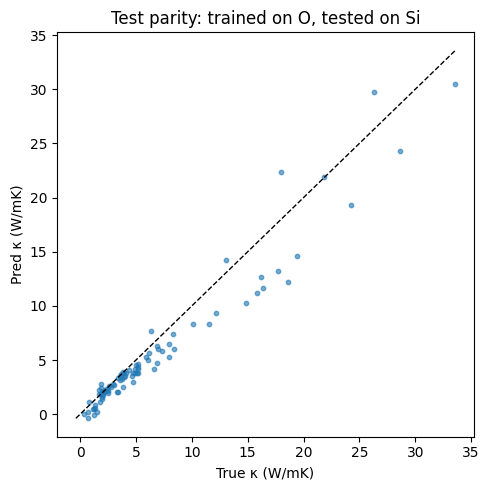

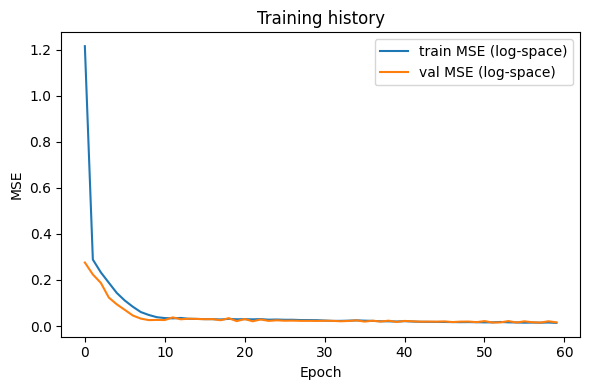

In [32]:
# Train
g0 = train_graphs[0]
x_dim = g0.x.size(-1)
e_dim = g0.edge_attr.size(-1)
u_dim = g0.u.size(-1)

model, history = train_model(
    train_graphs, val_graphs,
    x_dim=x_dim, e_dim=e_dim, u_dim=u_dim,
    epochs=60, batch_size=64, lr=1e-3, hidden=128, depth=3
)

# Evaluate on TEST = materials containing 2nd most frequent element
tlog_te, plog_te = predict_logs(model, test_graphs)
metrics_te = metrics_kappa_from_logs(tlog_te, plog_te)
print("\n=== TEST (2nd element) performance (κ-space) ===")
print(metrics_te)

# Plot parity in kappa space
true_k = np.expm1(tlog_te)
pred_k = np.expm1(plog_te)
parity_plot(true_k, pred_k, title=f"Test parity: trained on {top1_el}, tested on {top2_el}")

# Plot training curve
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train MSE (log-space)")
plt.plot(history["val_loss"], label="val MSE (log-space)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
train_el = "Al"
test_el = "Ni"

print("Train element:", train_el)
print("Test element :", test_el)

Train element: Al
Test element : Ni


In [34]:
df_train_pool = df[df["compound"].astype(str).apply(lambda x: contains_element(x, train_el))].copy()
df_test_pool  = df[df["compound"].astype(str).apply(lambda x: contains_element(x, test_el))].copy()

# Prefer EXCLUSIVE test set: contains Ni but NOT Al
df_test_excl = df_test_pool[
    ~df_test_pool["compound"].astype(str).apply(lambda x: contains_element(x, train_el))
].copy()

if len(df_test_excl) < 50:
    print(f"[Warn] Exclusive test set (contains {test_el} but not {train_el}) is small: {len(df_test_excl)}.")
    print(f"       Falling back to all materials containing {test_el}.")
    df_test = df_test_pool
else:
    df_test = df_test_excl

print(f"Train pool size (contains {train_el}):", len(df_train_pool))
print(f"Test pool size  (contains {test_el} but not {train_el} if possible):", len(df_test))

Train pool size (contains Al): 380
Test pool size  (contains Ni but not Al if possible): 283


In [35]:
train_graphs_all, sk1 = df_to_graphs(df_train_pool, k=KNN_K)
test_graphs, sk2 = df_to_graphs(df_test, k=KNN_K)

Building graphs:  46%|████▌     | 175/380 [00:00<00:00, 1744.39it/s]

dist_list finite? False min/max: 0.1648365003791636 inf
dist_list finite? False min/max: 0.4713743509017011 inf
dist_list finite? True min/max: 0.331734 0.7268517364332289
edge_attr col0 finite? True
dist_list finite? True min/max: 0.20536021208598318 0.41975319913849374
edge_attr col0 finite? True
dist_list finite? False min/max: 0.7071067811865476 inf
dist_list finite? True min/max: 0.20336414736132816 0.414578098794425
edge_attr col0 finite? True
dist_list finite? False min/max: 0.8660254037844386 inf
dist_list finite? False min/max: 0.3378725906136809 inf
dist_list finite? False min/max: 0.4713616229796397 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? True min/max: 0.2682230001141587 0.5812912882419623
edge_attr col0 finite? True
dist_list finite? False min/max: 0.8660254037844386 inf
dist_list finite? False min/max: 0.33615290692183514 inf
dist_list finite? False min/max: 0.44139302337939135 inf
dist_list finite? False min/max: 0.3511302620624432 in

Building graphs: 100%|██████████| 380/380 [00:00<00:00, 1580.39it/s]


dist_list finite? True min/max: 0.23862117565714908 0.7071067811865476
edge_attr col0 finite? True
dist_list finite? True min/max: 0.21198569833835487 0.4699750691214269
edge_attr col0 finite? True
dist_list finite? True min/max: 0.22746013397296677 0.5889310906566234
edge_attr col0 finite? True
dist_list finite? False min/max: 0.2960514671471838 inf
dist_list finite? True min/max: 0.20488867920156056 0.414578098794425
edge_attr col0 finite? True
dist_list finite? True min/max: 0.19301928694563145 0.5331272841873786
edge_attr col0 finite? True
dist_list finite? False min/max: 0.3475902469934966 inf
dist_list finite? False min/max: 0.3478394176196827 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.5329702813356482 inf
dist_list finite? True min/max: 0.2078062597396912 0.4922835831022603
edge_attr col0 finite? True
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.4713920299506559 inf
dist_list finite

Building graphs:   0%|          | 0/283 [00:00<?, ?it/s]

dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? True min/max: 0.30261287187428093 0.743703133413461
edge_attr col0 finite? True
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.4980220543630573 inf
dist_list finite? False min/max: 0.34321075381206456 inf
dist_list finite? True min/max: 0.20856321979678008 0.5177504499045944
edge_attr col0 finite? True
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.37492144985716674 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? True min/max: 0.20674982636026562 0.5086162509200821
edge_attr col0 finite? True
dist

Building graphs:  63%|██████▎   | 177/283 [00:00<00:00, 1768.20it/s]

dist_list finite? False min/max: 0.36387997802572203 inf
dist_list finite? False min/max: 0.40879863160240637 inf
dist_list finite? False min/max: 0.4464391638420626 inf
dist_list finite? False min/max: 0.3708900591553379 inf
dist_list finite? True min/max: 0.26640395742473505 0.6959514597658086
edge_attr col0 finite? True
dist_list finite? True min/max: 0.27488013025726327 0.5149583928697541
edge_attr col0 finite? True
dist_list finite? False min/max: 0.7071067811865476 inf
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? True min/max: 0.20606729252186043 0.5043949536494194
edge_attr col0 finite? True
dist_list finite? True min/max: 0.21727538150467024 0.7071067811865476
edge_attr col0 finite? True
dist_list finite? False min/max: 0.4202645276025565 inf
dist_list finite? False min/max: 0.5 inf
dist_list finite? False min/max: 0.34160297950395996 inf
dist_list finite? False min/max: 0.8660254037844386 inf
dist_list finite? True min/max: 0.2089174291628154 0.519

Building graphs: 100%|██████████| 283/283 [00:00<00:00, 1632.93it/s]

dist_list finite? True min/max: 0.2871811747764815 0.6170316521557059
edge_attr col0 finite? True
dist_list finite? False min/max: 0.2598225742155596 inf
dist_list finite? True min/max: 0.2621328178786472 0.6603803805209539
edge_attr col0 finite? True
dist_list finite? True min/max: 0.2877140657739347 0.6180933310496077
edge_attr col0 finite? True
dist_list finite? False min/max: 0.4330127018922193 inf
dist_list finite? True min/max: 0.34266760239656446 0.7071067811865476
edge_attr col0 finite? True
dist_list finite? False min/max: 0.341317215886688 inf
dist_list finite? True min/max: 0.35561248554008884 0.5623363847129226
edge_attr col0 finite? True
dist_list finite? True min/max: 0.20410659921472402 0.47114415745714183
edge_attr col0 finite? True
Built graphs: 71 / 283, skipped: 212
Example skip: (0, 'dist_list contains NaN/inf at indices [3, 7, 11, 15]')



=== TEST performance (train on Al, test on Ni) in κ-space ===
{'R2': 0.9188059568405151, 'MSE': 3.786749839782715}


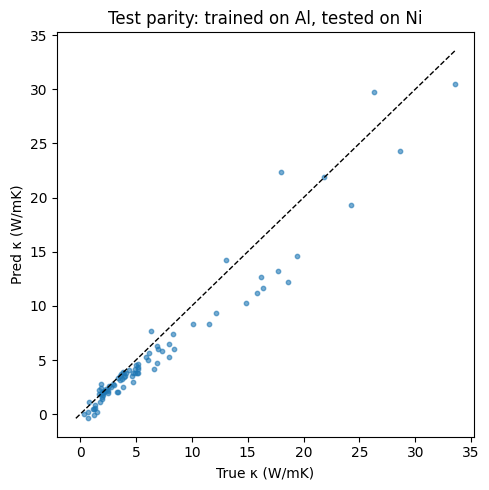

In [36]:
print(f"\n=== TEST performance (train on {train_el}, test on {test_el}) in κ-space ===")
print(metrics_te)

true_k = np.expm1(tlog_te)
pred_k = np.expm1(plog_te)
parity_plot(true_k, pred_k, title=f"Test parity: trained on {train_el}, tested on {test_el}")

/tmp/ipykernel_12442/2499108673.py:10: RuntimeWarning: invalid value encountered in log
  pred_logk = np.log(pred_k + eps)


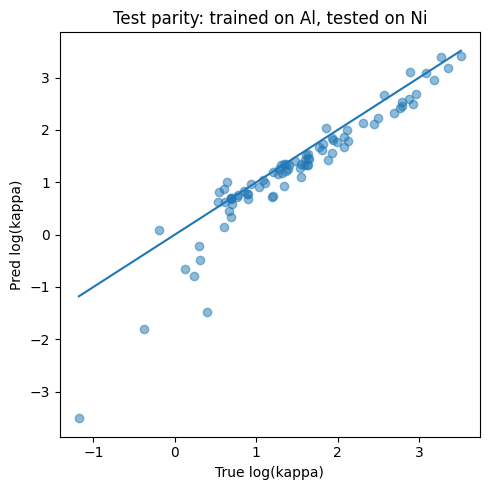

In [38]:
# ============================================================
# Convert to log(kappa)
# ============================================================
true_k = np.expm1(tlog_te)
pred_k = np.expm1(plog_te)

# avoid log(0)
eps = 1e-8
true_logk = np.log(true_k + eps)
pred_logk = np.log(pred_k + eps)

# ============================================================
# Parity plot (log kappa)
# ============================================================
plt.figure(figsize=(5, 5))

plt.scatter(true_logk, pred_logk, alpha=0.5)

lo = min(true_logk.min(), pred_logk.min())
hi = max(true_logk.max(), pred_logk.max())

plt.plot([lo, hi], [lo, hi])

plt.xlabel("True log(kappa)")
plt.ylabel("Pred log(kappa)")

plt.title(f"Test parity: trained on {train_el}, tested on {test_el}")

plt.tight_layout()
plt.show()

In [37]:
df_overlap = df_test_pool[
    df_test_pool["compound"].astype(str).apply(lambda x: contains_element(x, train_el))
].copy()

print(f"Materials containing both {train_el} and {test_el}: {len(df_overlap)}")
print(f"Exclusive {test_el}-only test materials: {len(df_test_excl)}")

Materials containing both Al and Ni: 22
Exclusive Ni-only test materials: 283
